# Notebook 6 — Generative Models: VAE & GAN
### DLA · Deep Learning Algorithms | PhD in Data Science 2028 | AIM
**Session 17 · Prof. Daniel Stanley Tan, PhD**

---

**Coverage:**
- Part 1: Discriminative vs generative models — the fundamental distinction
- Part 2: Density estimation — explicit vs implicit approaches
- Part 3: Variational Autoencoders (VAE) — explicit density via ELBO
- Part 4: Generative Adversarial Networks (GAN) — implicit density via adversarial training
- Case 1: Conditional & unconditional MNIST digit generation
- Case 2: Exploring and interpolating the latent space

**Prerequisites:** Notebook 1 (backpropagation), Notebook 2 (CNN architecture)

**Stack:** TensorFlow 2.x · Keras · NumPy · Matplotlib · SciPy


## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scipy.stats import norm

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow : 2.19.1
Keras      : 3.13.2
GPU devices: []


---
## Part 1: Discriminative vs Generative Models

### 1.1 The Fundamental Distinction

| Model type | Models | Goal | Output |
|---|---|---|---|
| **Discriminative** | CNN, RNN, MLP | $P(y \mid x)$ — given data, predict label | Class label / regression value |
| **Generative** | VAE, GAN, Diffusion | $P(x)$ or $P(x \mid y)$ — model the data itself | New synthetic samples |

A discriminative model learns the **decision boundary** between classes.
A generative model learns the **data distribution** — it must understand the full structure
of the data well enough to synthesise new examples indistinguishable from real ones.

### 1.2 Taxonomy of Generative Models

$$P(x) = \int P(x \mid z) P(z)\, dz$$

| Approach | How $P(x)$ is handled | Example models |
|---|---|---|
| **Explicit density (exact)** | $P(x)$ computed directly | Normalising Flows, PixelCNN |
| **Explicit density (approx)** | Lower bound on $\log P(x)$ | **VAE** |
| **Implicit density** | Sample from $P(x)$ without computing it | **GAN**, Diffusion |

### 1.3 The Latent Variable Framework

Both VAE and GAN assume data is generated by a low-dimensional **latent code** $z$:

$$z \sim P(z) = \mathcal{N}(0, I) \quad\longrightarrow\quad x = G(z)$$

The generator $G$ (or decoder) maps the simple Gaussian prior over $z$ to the complex
data distribution $P(x)$. Learning $G$ is the core challenge.


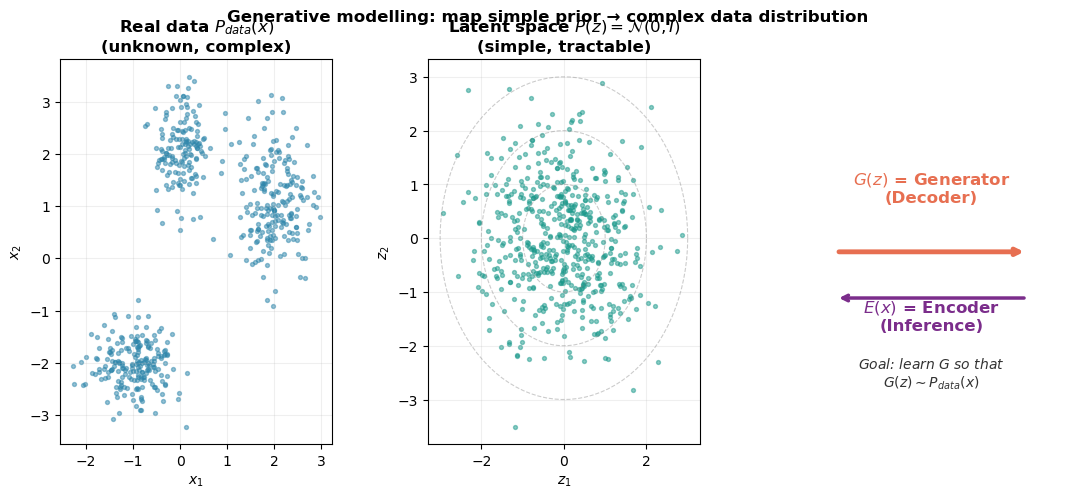

In [2]:
# ── 1.2 Visualise the generative modelling intuition ─────────────────────────

fig = plt.figure(figsize=(13, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel 1: Data distribution (2D Gaussian mixture for illustration)
ax1 = fig.add_subplot(gs[0])
np.random.seed(5)
data_pts = np.vstack([
    np.random.randn(200, 2) * [0.4, 0.8] + [2, 1],
    np.random.randn(200, 2) * [0.5, 0.4] + [-1, -2],
    np.random.randn(150, 2) * [0.3, 0.6] + [0, 2],
])
ax1.scatter(data_pts[:,0], data_pts[:,1], s=8, alpha=0.5, c='#2E86AB')
ax1.set_title('Real data $P_{data}(x)$\n(unknown, complex)', fontweight='bold')
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.grid(alpha=0.2)

# Panel 2: Latent space (simple prior)
ax2 = fig.add_subplot(gs[1])
z_pts = np.random.randn(550, 2)
ax2.scatter(z_pts[:,0], z_pts[:,1], s=8, alpha=0.5, c='#1B998B')
theta = np.linspace(0, 2*np.pi, 100)
for r in [1, 2, 3]:
    ax2.plot(r*np.cos(theta), r*np.sin(theta), 'gray', lw=0.8, ls='--', alpha=0.4)
ax2.set_title('Latent space $P(z) = \\mathcal{N}(0,I)$\n(simple, tractable)',
              fontweight='bold')
ax2.set_xlabel('$z_1$'); ax2.set_ylabel('$z_2$'); ax2.grid(alpha=0.2)

# Panel 3: Mapping arrow
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
ax3.annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
             arrowprops=dict(arrowstyle='->', color='#E76F51', lw=3.5),
             xycoords='axes fraction', textcoords='axes fraction')
ax3.text(0.5, 0.62, '$G(z)$ = Generator\n(Decoder)', ha='center', va='bottom',
         fontsize=12, color='#E76F51', fontweight='bold', transform=ax3.transAxes)
ax3.text(0.5, 0.38, '$E(x)$ = Encoder\n(Inference)', ha='center', va='top',
         fontsize=12, color='#7B2D8B', fontweight='bold', transform=ax3.transAxes)
ax3.annotate('', xy=(0.15, 0.38), xytext=(0.85, 0.38),
             arrowprops=dict(arrowstyle='->', color='#7B2D8B', lw=2.5),
             xycoords='axes fraction', textcoords='axes fraction')
ax3.text(0.5, 0.15, 'Goal: learn $G$ so that\n$G(z) \\sim P_{data}(x)$',
         ha='center', fontsize=10, color='#333', transform=ax3.transAxes,
         style='italic')

plt.suptitle('Generative modelling: map simple prior → complex data distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_generative_concept.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Part 2: Variational Autoencoders (VAE)

### 2.1 The ELBO Objective

We want to maximise the log-likelihood $\log P_\theta(x)$ of our data.
The posterior $P_\theta(z \mid x)$ is intractable, so we introduce an approximate
posterior $Q_\phi(z \mid x)$ (the encoder) and optimise the **ELBO**:

$$\log P_\theta(x) \geq \underbrace{\mathbb{E}_{Q_\phi}[\log P_\theta(x \mid z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(Q_\phi(z \mid x) \| P(z))}_{\text{KL regularisation}}$$

- **Reconstruction term**: the decoder should reconstruct $x$ from $z$ ← samples from the encoder
- **KL term**: the encoder's posterior should not stray too far from the prior $\mathcal{N}(0,I)$

### 2.2 The Reparameterisation Trick

The encoder outputs $\mu$ and $\log\sigma^2$ — we can't backpropagate through sampling.
Solution: express the sample as a **deterministic function** of the parameters plus an independent noise term:

$$z = \mu + \sigma \odot \epsilon \qquad \epsilon \sim \mathcal{N}(0, I)$$

Gradients flow through $\mu$ and $\sigma$; $\epsilon$ is just auxiliary noise.

### 2.3 KL Divergence (Closed Form for Gaussian)

For $Q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$ vs $P(z) = \mathcal{N}(0, I)$:

$$D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

No sampling needed — the KL has a closed form and is fully differentiable.


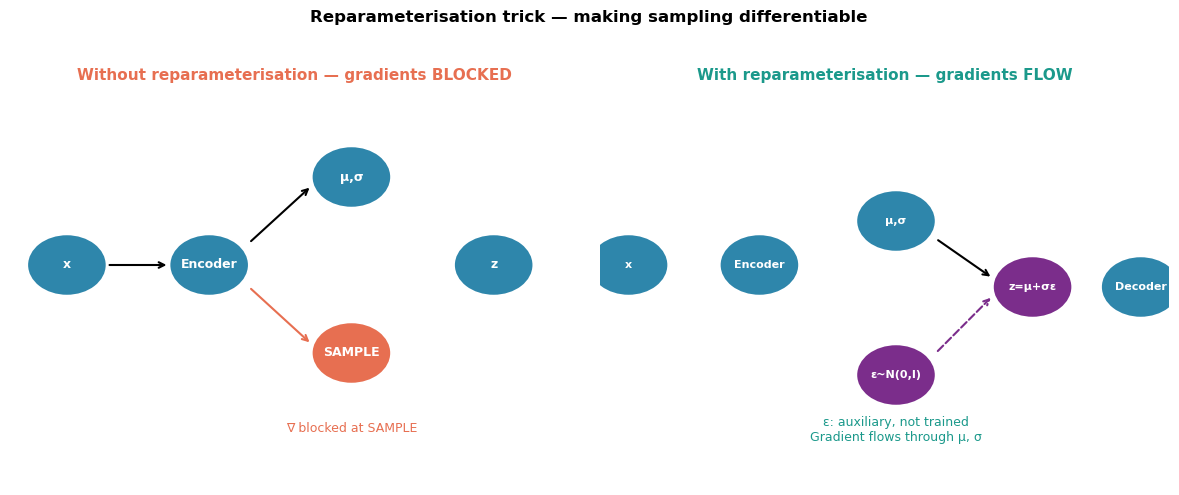

In [3]:
# ── 2.2 Visualise the reparameterisation trick ────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Without reparameterisation: gradient cannot flow through sampling node
ax1.axis('off')
nodes = {'x': (0.1, 0.5), 'Encoder': (0.35, 0.5),
         'μ,σ': (0.6, 0.7), 'SAMPLE': (0.6, 0.3),
         'z': (0.85, 0.5)}
ax1.text(0.5, 0.92, 'Without reparameterisation — gradients BLOCKED',
         ha='center', fontsize=11, fontweight='bold', transform=ax1.transAxes,
         color='#E76F51')
for name, (x, y) in nodes.items():
    color = '#E76F51' if name == 'SAMPLE' else '#2E86AB'
    ax1.add_patch(plt.Circle((x, y), 0.07, fc=color, ec='white', lw=1.5,
                              transform=ax1.transAxes, zorder=3))
    ax1.text(x, y, name, ha='center', va='center', fontsize=9,
             color='white', fontweight='bold', transform=ax1.transAxes, zorder=4)
ax1.annotate('', xy=(0.28, 0.5), xytext=(0.17, 0.5), xycoords='axes fraction',
             textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.annotate('', xy=(0.53, 0.68), xytext=(0.42, 0.55), xycoords='axes fraction',
             textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.annotate('', xy=(0.53, 0.32), xytext=(0.42, 0.45), xycoords='axes fraction',
             textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=1.5, color='#E76F51'))
ax1.text(0.6, 0.12, '∇ blocked at SAMPLE', ha='center', fontsize=9,
         color='#E76F51', transform=ax1.transAxes)

# With reparameterisation: gradient flows
ax2.axis('off')
nodes2 = {'x': (0.05,0.5), 'Encoder': (0.28,0.5), 'μ,σ': (0.52,0.6),
          'ε~N(0,I)': (0.52,0.25), 'z=μ+σε': (0.76,0.45), 'Decoder': (0.95,0.45)}
ax2.text(0.5, 0.92, 'With reparameterisation — gradients FLOW',
         ha='center', fontsize=11, fontweight='bold', transform=ax2.transAxes,
         color='#1B998B')
for name, (x, y) in nodes2.items():
    color = '#7B2D8B' if 'ε' in name else ('#1B998B' if 'z=' in name else '#2E86AB')
    ax2.add_patch(plt.Circle((x, y), 0.07, fc=color, ec='white', lw=1.5,
                              transform=ax2.transAxes, zorder=3))
    ax2.text(x, y, name, ha='center', va='center', fontsize=8,
             color='white', fontweight='bold', transform=ax2.transAxes, zorder=4)
ax2.annotate('', xy=(0.69, 0.47), xytext=(0.59, 0.56), xycoords='axes fraction',
             textcoords='axes fraction', arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.annotate('', xy=(0.69, 0.43), xytext=(0.59, 0.30), xycoords='axes fraction',
             textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', lw=1.5, color='#7B2D8B', ls='--'))
ax2.text(0.52, 0.10, 'ε: auxiliary, not trained\nGradient flows through μ, σ',
         ha='center', fontsize=9, color='#1B998B', transform=ax2.transAxes)

plt.suptitle('Reparameterisation trick — making sampling differentiable',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reparam.png', dpi=120, bbox_inches='tight')
plt.show()


In [4]:

# ── 2.3 VAE implementation ───────────────────────────────────────────────────

class Sampling(layers.Layer):
    """
    Reparameterisation trick as a Keras layer.
    Input : [mu, log_var] tensors of shape (batch, latent_dim)
    Output: sampled z = mu + exp(0.5 * log_var) * epsilon
    """
    def call(self, inputs):
        mu, log_var = inputs
        batch   = tf.shape(mu)[0]
        dim     = tf.shape(mu)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return mu + tf.exp(0.5 * log_var) * epsilon


class VAE(keras.Model):
    """
    Keras 3-compatible VAE wrapper with custom train/test steps.
    Tracks total loss, reconstruction loss, and KL divergence explicitly.
    """
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs, training=False):
        mu, log_var, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

    def _compute_losses(self, data, training=False):
        mu, log_var, z = self.encoder(data, training=training)
        reconstruction = self.decoder(z, training=training)

        # Binary cross-entropy per pixel, then sum over H,W,C and mean over batch
        bce = keras.losses.binary_crossentropy(data, reconstruction)
        recon_loss = keras.ops.mean(keras.ops.sum(bce, axis=(1, 2)))

        kl_term = 1 + log_var - keras.ops.square(mu) - keras.ops.exp(log_var)
        kl_loss = -0.5 * keras.ops.mean(keras.ops.sum(kl_term, axis=1))

        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data, training=True)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, recon_loss, kl_loss = self._compute_losses(data, training=False)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


def build_vae(latent_dim=2, img_shape=(28, 28, 1)):
    """
    Convolutional VAE for MNIST.
    Returns (encoder, decoder, vae) models.
    """
    H, W, C = img_shape

    # ── Encoder ───────────────────────────────────────────────────────────────
    enc_inp = keras.Input(shape=img_shape, name='enc_input')
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(enc_inp)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])
    encoder = keras.Model(enc_inp, [mu, log_var, z], name='VAE_Encoder')

    # ── Decoder ───────────────────────────────────────────────────────────────
    dec_inp = keras.Input(shape=(latent_dim,), name='dec_input')
    x = layers.Dense(7 * 7 * 64, activation='relu')(dec_inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    dec_out = layers.Conv2DTranspose(C, 3, padding='same', activation='sigmoid',
                                     name='reconstruction')(x)
    decoder = keras.Model(dec_inp, dec_out, name='VAE_Decoder')

    # ── VAE wrapper ───────────────────────────────────────────────────────────
    vae = VAE(encoder, decoder, name='VAE')
    vae.build((None, *img_shape))
    vae.compile(optimizer=keras.optimizers.Adam(1e-3))

    return encoder, decoder, vae

LATENT_DIM = 2   # 2D for visualisation; use 8-16 for better quality

encoder_vae, decoder_vae, vae_model = build_vae(latent_dim=LATENT_DIM)
encoder_vae.summary()
decoder_vae.summary()
print(f"\nVAE total parameters: {vae_model.count_params():,}")


Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ enc_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_input (InputLayer)          │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)


VAE total parameters: 485,957


In [5]:
# ── Load MNIST and train VAE ─────────────────────────────────────────────────

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.astype('float32')[..., np.newaxis] / 255.0
X_te = X_te.astype('float32')[..., np.newaxis] / 255.0

hist_vae = vae_model.fit(
    X_tr, X_tr,   # input = target (autoencoder)
    epochs=20, batch_size=128,
    validation_data=(X_te, X_te),
    callbacks=[keras.callbacks.EarlyStopping(patience=4,
               restore_best_weights=True, monitor='val_loss')],
    verbose=0
)
print(f"VAE training complete.  Epochs: {len(hist_vae.history['loss'])}")
final = hist_vae.history
print(f"  Final train loss  : {final['loss'][-1]:.2f}")
print(f"  Final recon loss  : {final['recon_loss'][-1]:.2f}")
print(f"  Final KL loss     : {final['kl_loss'][-1]:.4f}")


VAE training complete.  Epochs: 20
  Final train loss  : 144.42
  Final recon loss  : 137.78
  Final KL loss     : 6.6413


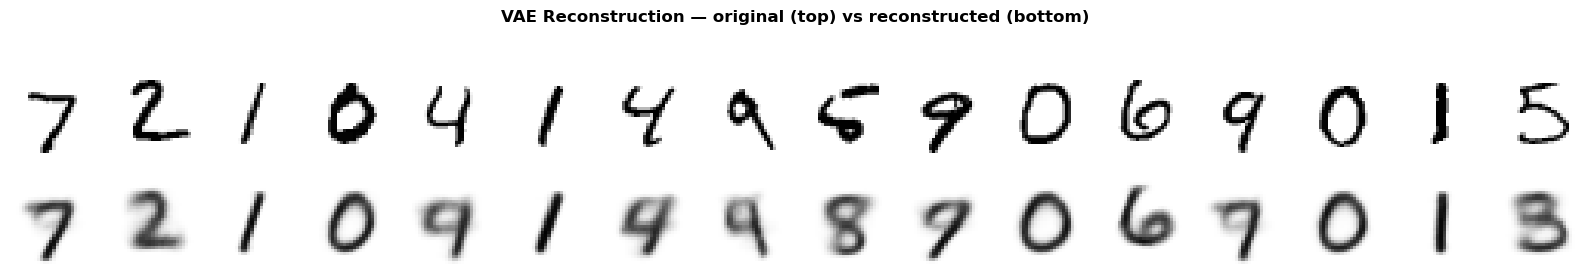

In [6]:
# ── Visualise reconstruction quality ─────────────────────────────────────────

samples = X_te[:16]
recons  = vae_model.predict(samples, verbose=0)

fig, axes = plt.subplots(2, 16, figsize=(16, 3))
for i in range(16):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray_r', vmin=0, vmax=1)
    axes[1, i].imshow(recons[i,  :, :, 0], cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].axis('off'); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('Recon', fontsize=9, fontweight='bold')
plt.suptitle('VAE Reconstruction — original (top) vs reconstructed (bottom)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_vae_recon.png', dpi=120, bbox_inches='tight')
plt.show()


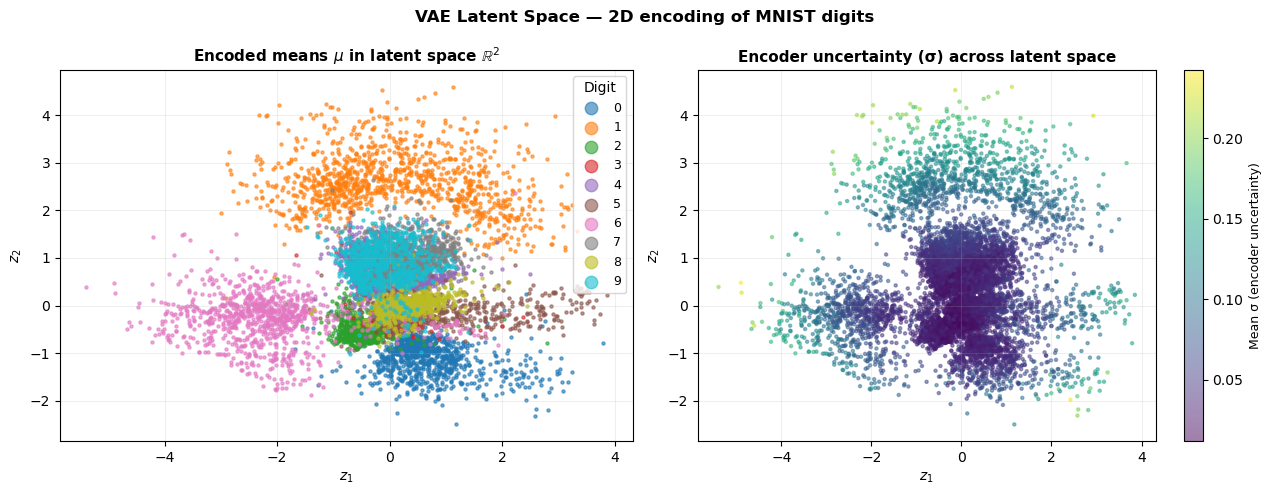

In [7]:
# ── Visualise the 2D latent space ─────────────────────────────────────────────

# Encode test set → (mu, log_var, z)
mu_all, lv_all, z_all = encoder_vae.predict(X_te, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors10  = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot means (not samples) — cleaner view of learned structure
for digit in range(10):
    mask = y_te == digit
    axes[0].scatter(mu_all[mask, 0], mu_all[mask, 1],
                    c=[colors10[digit]], s=5, alpha=0.6, label=str(digit))
axes[0].set_title('Encoded means $\mu$ in latent space $\mathbb{R}^2$',
                   fontweight='bold', fontsize=11)
axes[0].legend(title='Digit', markerscale=4, fontsize=9, loc='upper right')
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].grid(alpha=0.2)

# Posterior collapse check: plot sigma
sigma_all = np.exp(0.5 * lv_all)
axes[1].scatter(mu_all[:, 0], mu_all[:, 1],
                c=np.mean(sigma_all, axis=1), cmap='viridis', s=5, alpha=0.5)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Mean σ (encoder uncertainty)', fontsize=9)
axes[1].set_title('Encoder uncertainty (σ) across latent space',
                   fontweight='bold', fontsize=11)
axes[1].set_xlabel('$z_1$'); axes[1].set_ylabel('$z_2$')
axes[1].grid(alpha=0.2)

plt.suptitle('VAE Latent Space — 2D encoding of MNIST digits',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_vae_latent.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Part 3: Generative Adversarial Networks (GAN)

### 3.1 The Adversarial Framework (Goodfellow et al., 2014)

Two networks compete in a minimax game:
- **Generator** $G(z)$: maps noise $z \sim P(z)$ to fake samples; tries to fool $D$
- **Discriminator** $D(x)$: distinguishes real from fake; tries to catch $G$

**Value function** (minimax):
$$\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim P_{data}}[\log D(x)]
+ \mathbb{E}_{z \sim P_z}[\log(1 - D(G(z)))]$$

At the Nash equilibrium: $G$ has learned $P_{data}$ perfectly and $D$ outputs $\frac{1}{2}$ everywhere.

### 3.2 Training Algorithm

```
For each training step:
  1. Sample minibatch of real images x ~ P_data
  2. Sample minibatch of noise z ~ P(z)
  3. Train D: maximise log D(x) + log(1 - D(G(z)))
  4. Train G: minimise log(1 - D(G(z)))  [or maximise log D(G(z)) — non-saturating]
```

> **Critical:** $D$ and $G$ are updated **alternately**, not jointly.
> Freeze $G$'s weights while updating $D$, and vice versa.

### 3.3 Common Training Pathologies

| Problem | Symptom | Mitigation |
|---|---|---|
| **Mode collapse** | G generates only a few modes | Minibatch discrimination, diverse latents |
| **Vanishing gradient** | G loss stuck; D too strong | Label smoothing, balance updates |
| **Training instability** | Oscillation, divergence | WGAN-GP, spectral normalisation |

### 3.4 VAE vs GAN

| Property | VAE | GAN |
|---|---|---|
| Training | Stable (ELBO) | Unstable (minimax) |
| Sample quality | Blurry (MSE blur) | Sharp |
| Latent space | Structured, interpretable | Less structured |
| Inference | Encoder gives $z$ from $x$ | No inference |
| Density estimate | Approximate ELBO | None |


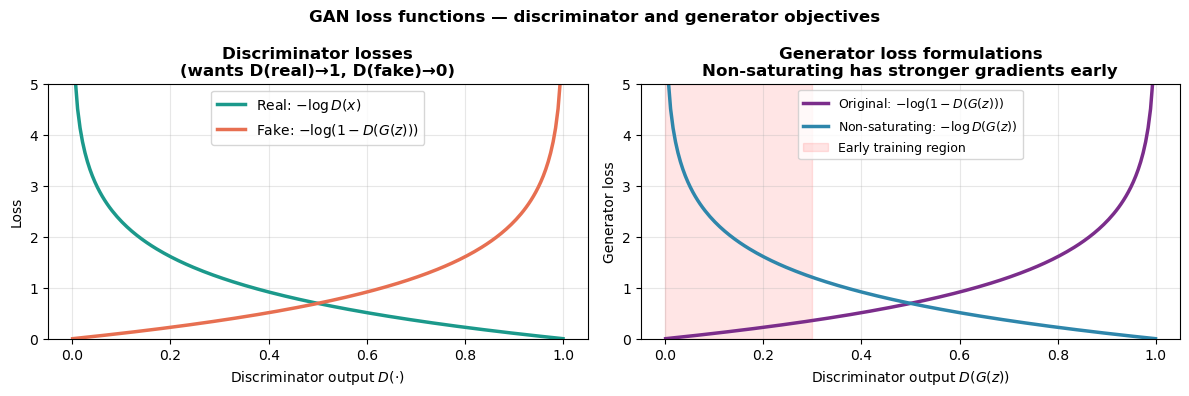

In [8]:
# ── 3.1 GAN loss functions visualised ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
d_out = np.linspace(0.001, 0.999, 200)

# Discriminator losses for real and fake inputs
d_real_loss = -np.log(d_out)              # -log D(x_real)
d_fake_loss = -np.log(1 - d_out)          # -log(1-D(G(z)))
axes[0].plot(d_out, d_real_loss, color='#1B998B', lw=2.5, label='Real: $-\log D(x)$')
axes[0].plot(d_out, d_fake_loss, color='#E76F51', lw=2.5, label='Fake: $-\log(1-D(G(z)))$')
axes[0].set_xlabel('Discriminator output $D(\cdot)$')
axes[0].set_ylabel('Loss')
axes[0].set_title('Discriminator losses\n(wants D(real)→1, D(fake)→0)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 5)

# Generator losses: original vs non-saturating
g_orig  = -np.log(1 - d_out)   # minimax: minimise log(1-D(G(z)))
g_nossat= -np.log(d_out)        # non-saturating: maximise log D(G(z))
axes[1].plot(d_out, g_orig,  color='#7B2D8B', lw=2.5, label='Original: $-\log(1-D(G(z)))$')
axes[1].plot(d_out, g_nossat, color='#2E86AB', lw=2.5, label='Non-saturating: $-\log D(G(z))$')
axes[1].axvspan(0, 0.3, alpha=0.1, color='red', label='Early training region')
axes[1].set_xlabel('Discriminator output $D(G(z))$')
axes[1].set_ylabel('Generator loss')
axes[1].set_title('Generator loss formulations\nNon-saturating has stronger gradients early',
                   fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 5)

plt.suptitle('GAN loss functions — discriminator and generator objectives',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gan_losses.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# ── 3.2 DC-GAN implementation for MNIST ──────────────────────────────────────

LATENT_DIM_GAN = 100

def build_generator(latent_dim):
    """
    Generator: z ∈ R^latent_dim → 28×28×1 image in [0,1].
    Architecture: Dense → Reshape → ConvTranspose stack.
    BatchNorm + LeakyReLU in hidden layers; tanh at output.
    """
    model = keras.Sequential([
        layers.Dense(7 * 7 * 256, use_bias=False,
                     input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((7, 7, 256)),                     # 7×7×256

        layers.Conv2DTranspose(128, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),                           # 7×7×128

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),                           # 14×14×64

        layers.Conv2DTranspose(1, 5, strides=2, padding='same',
                               use_bias=False, activation='tanh'),  # 28×28×1
    ], name='Generator')
    return model

def build_discriminator():
    """
    Discriminator: 28×28×1 image → real probability scalar.
    Architecture: Conv stack → Dense.
    LeakyReLU, Dropout for regularisation. No BatchNorm in D (training instability).
    """
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64,  5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1),    # logit — no sigmoid (use from_logits=True in loss)
    ], name='Discriminator')
    return model

generator_gan     = build_generator(LATENT_DIM_GAN)
discriminator_gan = build_discriminator()
generator_gan.summary()
discriminator_gan.summary()
print(f"\nGenerator params     : {generator_gan.count_params():,}")
print(f"Discriminator params : {discriminator_gan.count_params():,}")


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


Generator params     : 2,330,944
Discriminator params : 212,865


In [10]:
# ── 3.3 Custom GAN training loop ─────────────────────────────────────────────

class DCGAN(keras.Model):
    """
    Custom training loop for DC-GAN.
    Using from_logits=True — numerically more stable than sigmoid + BCE.
    """
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator     = generator
        self.discriminator = discriminator
        self.latent_dim    = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_opt  = d_optimizer
        self.g_opt  = g_optimizer
        self.bce    = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        noise      = tf.random.normal([batch_size, self.latent_dim])

        # ── Train Discriminator ───────────────────────────────────────────────
        with tf.GradientTape() as d_tape:
            fake_images = self.generator(noise, training=True)
            real_logits = self.discriminator(real_images,  training=True)
            fake_logits = self.discriminator(fake_images,  training=True)
            # Label smoothing: real → 0.9, fake → 0.1 (reduces overconfidence)
            d_loss_real = self.bce(tf.ones_like(real_logits) * 0.9, real_logits)
            d_loss_fake = self.bce(tf.zeros_like(fake_logits) + 0.1, fake_logits)
            d_loss      = d_loss_real + d_loss_fake
        d_grads = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

        # ── Train Generator (2× per D update — common heuristic) ─────────────
        for _ in range(2):
            noise = tf.random.normal([batch_size, self.latent_dim])
            with tf.GradientTape() as g_tape:
                fake_images = self.generator(noise, training=True)
                fake_logits = self.discriminator(fake_images, training=True)
                # Non-saturating loss: maximise log D(G(z)) = minimise -log D(G(z))
                g_loss = self.bce(tf.ones_like(fake_logits), fake_logits)
            g_grads = g_tape.gradient(g_loss, self.generator.trainable_variables)
            self.g_opt.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        return {'d_loss': d_loss, 'g_loss': g_loss}

# Rescale images to [-1, 1] to match tanh output
X_tr_gan = X_tr * 2.0 - 1.0   # [0,1] → [-1,1]
train_dataset = tf.data.Dataset.from_tensor_slices(X_tr_gan)    .shuffle(60000).batch(256).prefetch(tf.data.AUTOTUNE)

dcgan = DCGAN(generator_gan, discriminator_gan, LATENT_DIM_GAN)
dcgan.compile(
    d_optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(2e-4, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True)
)
print("DC-GAN compiled. Training...")
hist_gan = dcgan.fit(train_dataset, epochs=30, verbose=0)
print(f"Training complete.")
print(f"  Final D loss : {hist_gan.history['d_loss'][-1]:.4f}")
print(f"  Final G loss : {hist_gan.history['g_loss'][-1]:.4f}")


DC-GAN compiled. Training...
Training complete.
  Final D loss : 1.4049
  Final G loss : 0.6721


---
## Case 1: Conditional & Unconditional MNIST Generation

**Unconditional GAN** (above): generate random digit images — no control over which digit.

**Conditional GAN (cGAN)**: feed class label $y$ to both $G$ and $D$:
$$G(z, y) \to \tilde{x} \qquad D(x, y) \to \text{real/fake}$$

Now we can request specific digits at generation time.

**Conditional VAE (CVAE)**: feed class label to both encoder and decoder.
Deterministic generation of specific classes from the prior.


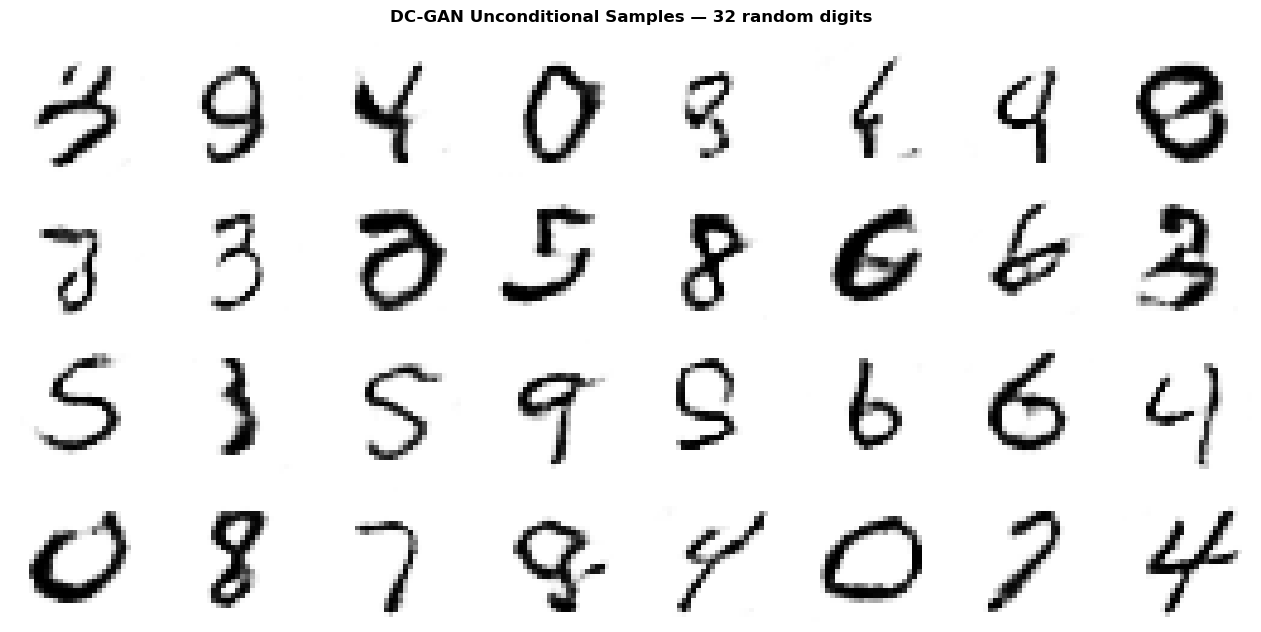

In [11]:
# ── Case 1a: Unconditional generation ────────────────────────────────────────

def generate_and_plot(model, latent_dim, n_rows=4, n_cols=8, title='Generated'):
    """Generate a grid of images from a trained generator."""
    noise = tf.random.normal([n_rows * n_cols, latent_dim])
    imgs  = model(noise, training=False).numpy()
    imgs  = (imgs + 1.0) / 2.0   # [-1,1] → [0,1]
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*1.6, n_rows*1.6))
    for ax, img in zip(axes.flat, imgs):
        ax.imshow(img[:,:,0], cmap='gray_r', vmin=0, vmax=1)
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

fig = generate_and_plot(generator_gan, LATENT_DIM_GAN,
                        title='DC-GAN Unconditional Samples — 32 random digits')
plt.savefig('fig_gan_samples.png', dpi=120, bbox_inches='tight')
plt.show()


In [12]:
# ── Case 1b: Conditional VAE (CVAE) ─────────────────────────────────────────

N_CLASSES   = 10
LATENT_CVAE = 8

class CVAE(keras.Model):
    """
    Keras 3-compatible Conditional VAE wrapper with custom train/test steps.
    Inputs are [image, one_hot_label].
    """
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs, training=False):
        images, labels = inputs
        mu, log_var, z = self.encoder([images, labels], training=training)
        return self.decoder([z, labels], training=training)

    def _unpack(self, data):
        # Supports both:
        #   fit([X, y], X)
        #   fit((X, y))
        #   fit(([X, y], X))
        if isinstance(data, tuple):
            inputs = data[0]
        else:
            inputs = data

        if isinstance(inputs, (list, tuple)) and len(inputs) == 2:
            images, labels = inputs
        else:
            raise ValueError("CVAE expects inputs as [images, one_hot_labels].")
        return images, labels

    def _compute_losses(self, data, training=False):
        images, labels = self._unpack(data)
        mu, log_var, z = self.encoder([images, labels], training=training)
        reconstruction = self.decoder([z, labels], training=training)

        bce = keras.losses.binary_crossentropy(images, reconstruction)
        recon_loss = keras.ops.mean(keras.ops.sum(bce, axis=(1, 2)))
        kl_term = 1 + log_var - keras.ops.square(mu) - keras.ops.exp(log_var)
        kl_loss = -0.5 * keras.ops.mean(keras.ops.sum(kl_term, axis=1))
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data, training=True)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        total_loss, recon_loss, kl_loss = self._compute_losses(data, training=False)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


def build_cvae(latent_dim=8, n_classes=10, img_shape=(28,28,1)):
    """
    Conditional VAE: both encoder and decoder receive class label.
    Label is one-hot encoded and concatenated to the input.
    """
    H, W, C = img_shape

    # ── Encoder ───────────────────────────────────────────────────────────────
    img_inp   = keras.Input(shape=img_shape, name='img_input')
    lbl_inp   = keras.Input(shape=(n_classes,), name='label_input')
    lbl_img   = layers.Dense(H * W)(lbl_inp)
    lbl_img   = layers.Reshape((H, W, 1))(lbl_img)
    x = layers.Concatenate(axis=-1)([img_inp, lbl_img])  # (H,W,2)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    mu      = layers.Dense(latent_dim, name='cvae_mu')(x)
    log_var = layers.Dense(latent_dim, name='cvae_logvar')(x)
    z       = Sampling(name='cvae_z')([mu, log_var])
    encoder_c = keras.Model([img_inp, lbl_inp], [mu, log_var, z], name='CVAE_Encoder')

    # ── Decoder ───────────────────────────────────────────────────────────────
    z_inp = keras.Input(shape=(latent_dim,), name='z_input')
    lbl_d = keras.Input(shape=(n_classes,), name='dec_label')
    x = layers.Concatenate()([z_inp, lbl_d])
    x = layers.Dense(7 * 7 * 64, activation='relu')(x)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    dec_out = layers.Conv2DTranspose(C, 3, padding='same', activation='sigmoid')(x)
    decoder_c = keras.Model([z_inp, lbl_d], dec_out, name='CVAE_Decoder')

    cvae = CVAE(encoder_c, decoder_c, name='CVAE')
    cvae.build([(None, *img_shape), (None, n_classes)])
    cvae.compile(optimizer=keras.optimizers.Adam(1e-3))

    return encoder_c, decoder_c, cvae

enc_cvae, dec_cvae, cvae_model = build_cvae(LATENT_CVAE, N_CLASSES)
print(f"CVAE parameters: {cvae_model.count_params():,}")

# Prepare one-hot labels
y_tr_oh = keras.utils.to_categorical(y_tr, N_CLASSES)
y_te_oh = keras.utils.to_categorical(y_te, N_CLASSES)

hist_cvae = cvae_model.fit(
    [X_tr, y_tr_oh], X_tr,
    epochs=20, batch_size=128,
    validation_data=([X_te, y_te_oh], X_te),
    callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=0
)
print(f"CVAE training complete. Final loss: {hist_cvae.history['loss'][-1]:.2f}")

CVAE parameters: 546,593
CVAE training complete. Final loss: 95.99


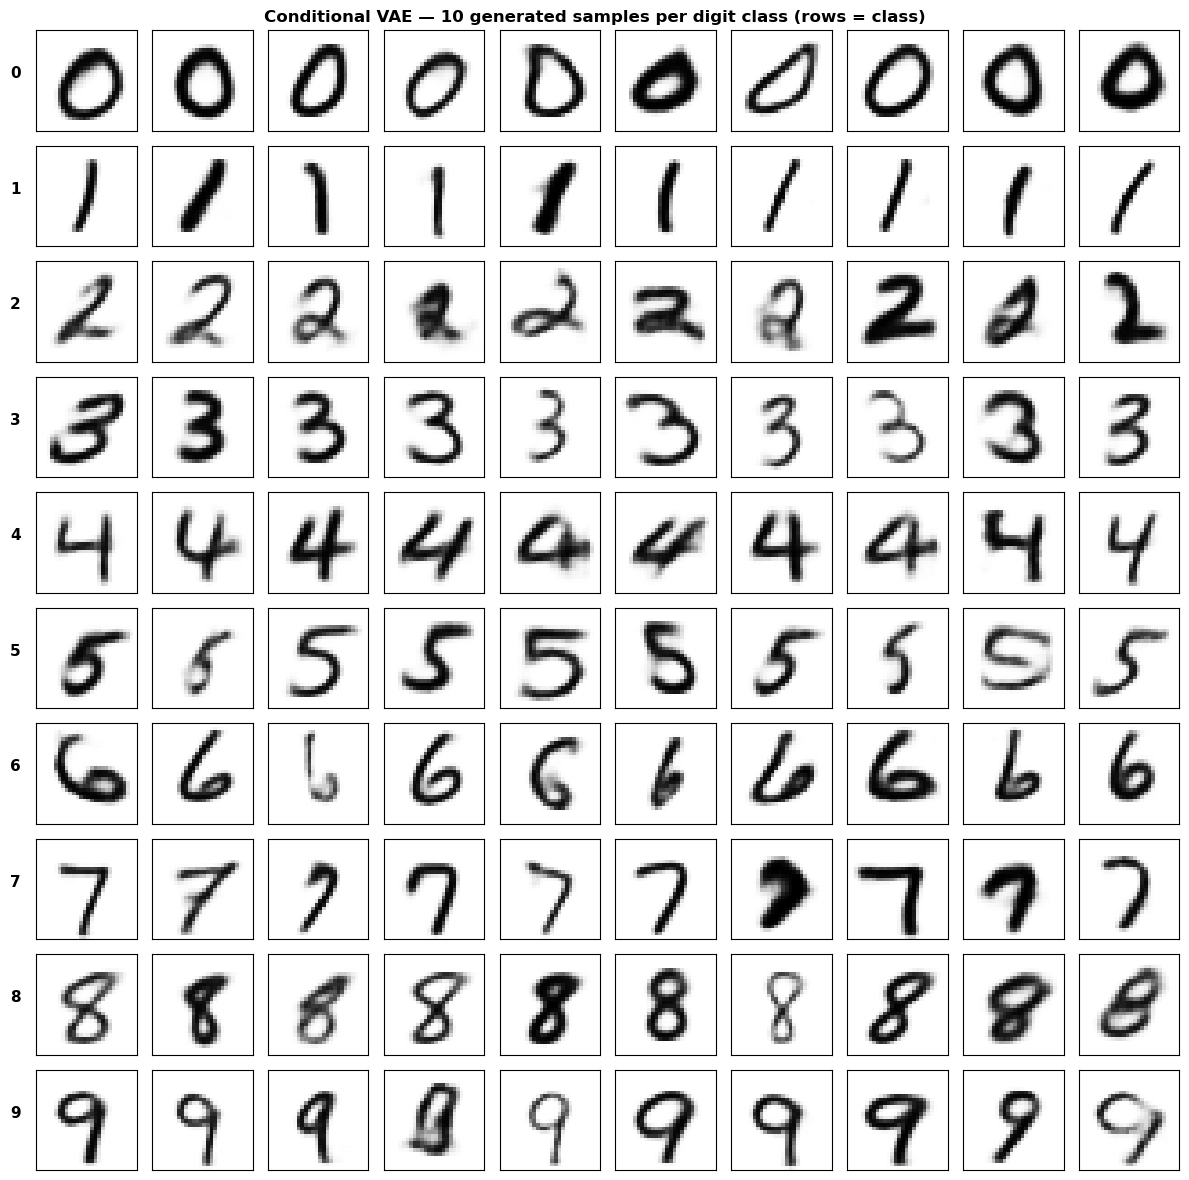

Each row: 10 stochastic samples of the same digit class from CVAE prior.


In [13]:
# ── Generate specific digits with CVAE ───────────────────────────────────────

# Generate 10 samples of each digit class
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    label_oh = np.zeros((10, N_CLASSES), dtype='float32')
    label_oh[:, digit] = 1.0
    z_sample = np.random.randn(10, LATENT_CVAE).astype('float32')
    generated = dec_cvae.predict([z_sample, label_oh], verbose=0)
    for col in range(10):
        axes[digit, col].imshow(generated[col, :, :, 0], cmap='gray_r', vmin=0, vmax=1)
        if col == 0:
            axes[digit, col].set_ylabel(str(digit), fontsize=11, fontweight='bold',
                                        rotation=0, labelpad=15)
        axes[digit, col].set_xticks([]); axes[digit, col].set_yticks([])

plt.suptitle('Conditional VAE — 10 generated samples per digit class (rows = class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cvae_conditional.png', dpi=120, bbox_inches='tight')
plt.show()
print("Each row: 10 stochastic samples of the same digit class from CVAE prior.")


---
## Case 2: Exploring and Interpolating the Latent Space

A key advantage of the VAE is its **structured latent space** — the KL regularisation
forces the posterior to be close to the Gaussian prior, ensuring smooth coverage.

Two key experiments:
1. **2D grid traversal** — decode every point on a regular grid → visualise the full manifold
2. **Interpolation** — decode points on a straight path between two latent codes →
   smooth transition between two digits (morphing)

**Why does GAN not have this?** There is no encoder in a vanilla GAN — we cannot
invert an image to its latent code. (GAN Inversion and Encoder4Editing address this.)


In [ ]:
# ── Case 2a: 2D latent space grid traversal (VAE, latent_dim=2) ─────────────

# Use the 2D VAE trained earlier (LATENT_DIM=2)
n_grid = 20
grid_x = norm.ppf(np.linspace(0.05, 0.95, n_grid))   # quantiles of N(0,1)
grid_y = norm.ppf(np.linspace(0.05, 0.95, n_grid))

fig, axes = plt.subplots(n_grid, n_grid, figsize=(12, 12))
fig.subplots_adjust(hspace=0, wspace=0)

for row_i, yi in enumerate(grid_y):
    for col_j, xj in enumerate(grid_x):
        z_pt   = np.array([[xj, yi]], dtype='float32')
        img_pt = decoder_vae.predict(z_pt, verbose=0)
        axes[row_i, col_j].imshow(img_pt[0,:,:,0], cmap='gray_r', vmin=0, vmax=1)
        axes[row_i, col_j].axis('off')

plt.suptitle(
    f'VAE 2D Latent Space Grid ({n_grid}×{n_grid} traversal)\n'
    'Each cell = decoded sample at that latent coordinate',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('fig_vae_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Grid covers z₁ ∈ [{grid_x[0]:.2f}, {grid_x[-1]:.2f}],  "
      f"z₂ ∈ [{grid_y[0]:.2f}, {grid_y[-1]:.2f}]")


In [ ]:
# ── Case 2b: Latent space interpolation ──────────────────────────────────────

def interpolate_latent(encoder, decoder, x_start, x_end, n_steps=12):
    """
    Linearly interpolate between the latent codes of two images.
    Uses the encoder mean (mu) — not the sample — for deterministic results.
    """
    mu_start, _, _ = encoder.predict(x_start[np.newaxis], verbose=0)
    mu_end,   _, _ = encoder.predict(x_end[np.newaxis],   verbose=0)
    alphas = np.linspace(0, 1, n_steps)
    z_path = np.array([mu_start[0]*(1-a) + mu_end[0]*a for a in alphas])
    imgs   = decoder.predict(z_path.astype('float32'), verbose=0)
    return imgs

# Pick representative examples for each desired pair
pair_digits = [(0, 8), (1, 7), (3, 5)]
n_steps     = 12

fig, axes = plt.subplots(len(pair_digits), n_steps, figsize=(16, 5))
for row, (d_start, d_end) in enumerate(pair_digits):
    idx_s = np.where(y_te == d_start)[0][0]
    idx_e = np.where(y_te == d_end)[0][0]
    interp_imgs = interpolate_latent(encoder_vae, decoder_vae,
                                     X_te[idx_s], X_te[idx_e], n_steps)
    for col in range(n_steps):
        axes[row, col].imshow(interp_imgs[col,:,:,0], cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f'{d_start}→{d_end}', fontsize=10,
                                      fontweight='bold', rotation=0, labelpad=20)
    axes[row, 0].set_title('Start', fontsize=8)
    axes[row, n_steps//2].set_title('Mid', fontsize=8)
    axes[row, -1].set_title('End',  fontsize=8)

plt.suptitle(
    'Latent Space Interpolation — smooth morphing between digit classes\n'
    '(only possible because VAE enforces continuous latent structure)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_interpolation.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ── Case 2c: Latent space arithmetic ─────────────────────────────────────────
# Concept: z_4 - z_0 ≈ "angle/roundness" direction

def get_class_mean_z(encoder, X, y, target_class, n=200):
    """Compute the mean latent vector (mu) for a digit class."""
    idx   = np.where(y == target_class)[0][:n]
    mu, _, _ = encoder.predict(X[idx], batch_size=64, verbose=0)
    return mu.mean(axis=0)

mean_z = {}
for d in range(10):
    mean_z[d] = get_class_mean_z(encoder_vae, X_te, y_te, d)

# Arithmetic: z_class_a - z_class_b + z_class_c ≈ z_class_d ?
combos = [
    (1, 7, 4, '1 − 7 + 4'),   # remove vertical stroke, add loop
    (3, 8, 0, '3 − 8 + 0'),
    (5, 6, 9, '5 − 6 + 9'),
]

fig, axes = plt.subplots(len(combos), 5, figsize=(10, 7))
col_titles = ['Class A', '− Class B', '+ Class C', '= Result', 'Nearest GT']

for row, (a, b, c, formula) in enumerate(combos):
    z_result = mean_z[a] - mean_z[b] + mean_z[c]
    z_result = z_result[np.newaxis].astype('float32')
    img_a    = decoder_vae.predict(mean_z[a][np.newaxis].astype('float32'), verbose=0)[0]
    img_b    = decoder_vae.predict(mean_z[b][np.newaxis].astype('float32'), verbose=0)[0]
    img_c    = decoder_vae.predict(mean_z[c][np.newaxis].astype('float32'), verbose=0)[0]
    img_res  = decoder_vae.predict(z_result, verbose=0)[0]

    # Find nearest digit in test set
    all_mu   = np.stack([mean_z[d] for d in range(10)])
    dists    = np.linalg.norm(all_mu - z_result[0], axis=1)
    nearest  = np.argmin(dists)
    img_near = decoder_vae.predict(mean_z[nearest][np.newaxis].astype('float32'), verbose=0)[0]

    for col, img in enumerate([img_a, img_b, img_c, img_res, img_near]):
        axes[row, col].imshow(img[:,:,0], cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(formula, fontsize=10, fontweight='bold',
                            rotation=0, labelpad=55)
    axes[row, 4].set_title(f'→ {nearest}?', fontsize=9, color='#2E86AB',
                           fontweight='bold')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Latent Space Arithmetic — class mean vectors follow algebraic structure',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_latent_arithmetic.png', dpi=120, bbox_inches='tight')
plt.show()
print("Note: arithmetic in latent space works best with disentangled representations.")
print("More structured latent spaces emerge with β-VAE (higher KL weight).")


In [ ]:
# ── Training dynamics comparison: VAE vs GAN ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VAE convergence (stable, monotone)
epochs_vae = range(len(hist_vae.history['loss']))
axes[0].plot(hist_vae.history['loss'],     label='Train total',  color='#2E86AB', lw=2)
axes[0].plot(hist_vae.history['val_loss'], label='Val total',    color='#2E86AB', lw=2, ls='--')
axes[0].plot(hist_vae.history['recon_loss'], label='Recon',      color='#1B998B', lw=1.5, alpha=0.7)
axes[0].plot(hist_vae.history['kl_loss'],    label='KL',         color='#E76F51', lw=1.5, alpha=0.7)
axes[0].set_title('VAE training — stable convergence\n(ELBO maximisation)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('ELBO loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# GAN training (adversarial, noisier)
axes[1].plot(hist_gan.history['d_loss'], label='Discriminator', color='#E76F51', lw=2)
axes[1].plot(hist_gan.history['g_loss'], label='Generator',     color='#2E86AB', lw=2)
axes[1].axhline(np.log(2), color='gray', ls=':', lw=1.5,
                label=f'Equilibrium ≈ {np.log(2):.3f}')
axes[1].set_title('GAN training — adversarial dynamics\n(minimax game)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('VAE vs GAN: training stability comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_training_dynamics.png', dpi=120, bbox_inches='tight')
plt.show()
print("At Nash equilibrium, GAN losses should converge to log(2) ≈ 0.693.")
print("Both approaching log(2) indicates a balanced adversarial game.")


---
## Summary & Exam Notes

**1. Discriminative vs generative:** discriminative models learn $P(y|x)$ — a boundary.
Generative models learn $P(x)$ or $P(x|y)$ — the full data distribution.
The latter is strictly harder but enables synthesis, interpolation, and density estimation.

**2. ELBO:** the VAE objective is the Evidence Lower BOund:
$\mathcal{L} = \mathbb{E}_Q[\log P(x|z)] - D_{KL}(Q(z|x) \| P(z))$
Maximising ELBO simultaneously improves reconstruction quality AND regularises the
latent space to look like the prior.

**3. Reparameterisation trick:** replaces the non-differentiable sampling step
$z \sim Q_\phi(z|x)$ with $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0,I)$.
Gradients now flow through $\mu$ and $\sigma$ via the chain rule.

**4. KL divergence (closed form):** for Gaussian VAE,
$D_{KL} = -\frac{1}{2}\sum_j(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)$.
No sampling or numerical integration needed.

**5. GAN minimax:** $\min_G \max_D V(D,G)$. At Nash equilibrium, $D \to \frac{1}{2}$,
$G \to P_{data}$. Non-saturating generator loss ($-\log D(G(z))$) prevents vanishing
gradients in early training.

**6. Label smoothing:** replace hard targets (0,1) with soft targets (0.1, 0.9).
Prevents discriminator from becoming overconfident and killing generator gradients.

**7. Training instability pathologies:** mode collapse (G only generates a few modes),
vanishing gradients (D too strong), oscillation. Mitigations: WGAN-GP (gradient penalty),
spectral normalisation, progressive growing.

**8. VAE vs GAN trade-offs:**
- VAE: stable, structured latent space, blurry samples (MSE penalty blurs uncertainty)
- GAN: unstable, no encoder, sharp samples, harder to evaluate

**9. Latent space properties:** the KL regularisation ensures the VAE latent space is
continuously covered by $\mathcal{N}(0,I)$ → smooth interpolation and arithmetic.
GAN latent spaces have similar geometry but require GAN Inversion to use.

**10. Evaluation metrics:**
- **FID** (Fréchet Inception Distance) — distributional similarity; lower = better
- **IS** (Inception Score) — quality + diversity; higher = better
- **ELBO** — tractable proxy for VAE log-likelihood; higher = better

---
*DLA Notebook 6 — Deep Learning Algorithms · PhD in Data Science 2028 · AIM*
*Prof. Daniel Stanley Tan, PhD · Session 17*
